In [ ]:
import torch 
from torch import nn
import numpy as np
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from PIL import Image
import PIL
from glob import glob
import random
import os
from matplotlib.pyplot import imshow
from PIL import ImageFile
from skimage import io
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
#!kaggle datasets download arnaud58/flickrfaceshq-dataset-ffhq
!kaggle datasets download jessicali9530/celeba-dataset
!mkdir data
#!unzip flickrfaceshq-dataset-ffhq.zip

mkdir: cannot create directory ‘/root/.kaggle’: File exists
100% 1.33G/1.33G [00:10<00:00, 106MB/s]
100% 1.33G/1.33G [00:10<00:00, 135MB/s]
mkdir: cannot create directory ‘data’: File exists


In [ ]:
!unzip celeba-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: img_align_celeba/img_align_celeba/078947.jpg  
  inflating: img_align_celeba/img_align_celeba/078948.jpg  
  inflating: img_align_celeba/img_align_celeba/078949.jpg  
  inflating: img_align_celeba/img_align_celeba/078950.jpg  
  inflating: img_align_celeba/img_align_celeba/078951.jpg  
  inflating: img_align_celeba/img_align_celeba/078952.jpg  
  inflating: img_align_celeba/img_align_celeba/078953.jpg  
  inflating: img_align_celeba/img_align_celeba/078954.jpg  
  inflating: img_align_celeba/img_align_celeba/078955.jpg  
  inflating: img_align_celeba/img_align_celeba/078956.jpg  
  inflating: img_align_celeba/img_align_celeba/078957.jpg  
  inflating: img_align_celeba/img_align_celeba/078958.jpg  
  inflating: img_align_celeba/img_align_celeba/078959.jpg  
  inflating: img_align_celeba/img_align_celeba/078960.jpg  
  inflating: img_align_celeba/img_align_celeba/078961.jpg  
  inflating: img_align_celeba/img_align_celeba/07

In [ ]:
!rm img_align_celeba/img_align_celeba/083947.jpg

In [ ]:
!mv *.png data

In [ ]:
dir_name = 'img_align_celeba/img_align_celeba'
img_sizes = [4, 8, 16, 32, 64, 128, 256, 512]
input_channels = [256, 256, 256, 256, 256, 128, 64, 32]
output_channels = [256, 256, 256, 256, 128, 64, 32, 16]
batch_sizes=[128, 128, 64, 64, 32, 16, 8, 4]
alphas = list(np.linspace(0.1, 1, num=len(img_sizes), endpoint=True))
z_dim = 256
w_dim = z_dim

In [ ]:
alphas

[0.1,
 0.2285714285714286,
 0.3571428571428572,
 0.48571428571428577,
 0.6142857142857143,
 0.7428571428571429,
 0.8714285714285716,
 1.0]

In [ ]:
class FFHQDataset(torch.utils.data.Dataset):
  def __init__(self, root_dir, transform=None):
    self.root_dir = root_dir
    self.paths = os.listdir(root_dir)
    self.transform = transform 
  
  def __len__(self):
    return len(self.paths)
  
  def __getitem__(self, index):
    img_path = os.path.join(self.root_dir, self.paths[index])
    image = Image.open(img_path)
    
    if self.transform:
      image = self.transform(image)
    
    return image

In [ ]:
transform = transforms.Compose([
    transforms.Resize((4, 4)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x*2-1)
])
dataset = FFHQDataset(dir_name, transform)

In [ ]:
len(dataset)

83947

In [ ]:
data_loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [ ]:
for d in data_loader:
  print(d.shape)

torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
torch.Size([128, 3, 4, 4])
t

##Crucial architecture parts

#Equalized layers

In [ ]:
class EqualizedConv(nn.Module):
  '''
  Equalized Linear layer:
  Parameters:
        in: input channels count
        out: output channels count
  '''
  def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, gain=2):
    super(EqualizedConv, self).__init__()

    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
    self.scale = (gain / (in_channels * kernel_size**2))**0.5
    self.bias = self.conv.bias
    self.conv.bias = None

    #initialize weights
    nn.init.normal_(self.conv.weight)
    nn.init.zeros_(self.bias)
  
  def forward(self, x):
    return self.conv(x * self.scale) + self.bias.view(1, self.bias.shape[0], 1, 1)


In [ ]:
class EqualizedLinear(nn.Module):
  '''
  Equalized Linear layer
  Parameters:
        in_dim: input dimension
        out_dim: output dimension
  '''
  def __init__(self, in_dim, out_dim, gain=2):
    super(EqualizedLinear, self).__init__()
    
    self.linear = nn.Linear(in_dim, out_dim)
    self.bias = self.linear.bias
    self.linear.bias = None

    self.scale = (gain / in_dim)**0.5

    #initialize linear layer
    nn.init.normal_(self.linear.weight)
    nn.init.zeros_(self.bias)
  
  def forward(self, x):
    return self.linear(x * self.scale) + self.bias


Mapping part

In [ ]:
class Mapping(nn.Module):
  '''
  class for mapping part:
    Parameters:
          z_dim: dimention of latent space vector
          hidden_dim: dimention of hidden space 
  '''

  def __init__(self, z_dim, hidden_dim):
    super(Mapping, self).__init__()

    self.z_dim = z_dim
    self.hidden_dim = hidden_dim
    self.w_dim = z_dim

    inner_layers = nn.ModuleList()
    inner_layers.append(EqualizedLinear(z_dim, hidden_dim))
    for i in range(4):
      inner_layers.append(EqualizedLinear(hidden_dim, hidden_dim))
    
    inner_layers.append(EqualizedLinear(hidden_dim, self.w_dim))
    inner_layers.append(nn.ReLU())

    self.mapping = nn.Sequential(*inner_layers)
  
  def forward(self, z):
    '''
    Returns mapped vectors from z to w space
    Prameters:
          z: vectors of latent z space
    '''
    return self.mapping(z)

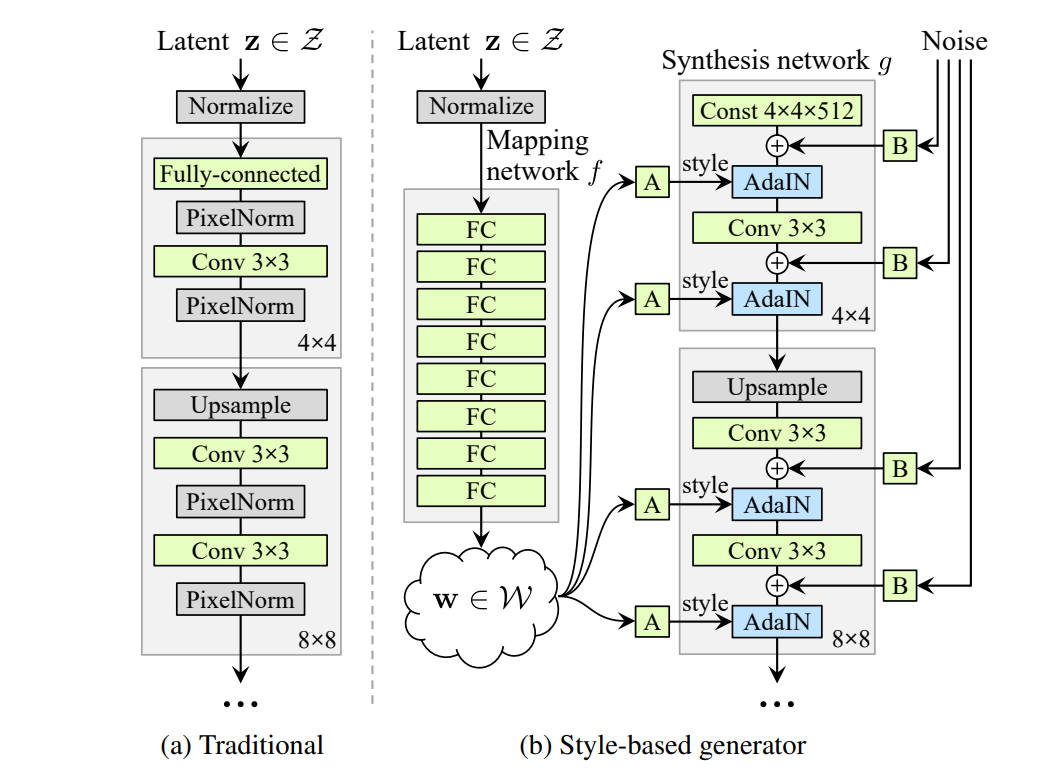

In [ ]:
class NoiceChannel(nn.Module):
  '''
  Noice with weights channel estimate
  '''
  def __init__(self, in_channels):
    super(NoiceChannel, self).__init__()

    self.weights = nn.Parameter(torch.normal(0, 1, size=(1, in_channels, 1, 1)))

  def forward(self, images):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    B, C, H, W = images.shape
  
    noice_shape = (B, 1, H, W)

    noice = torch.randn(size=noice_shape, device=device)
    
    return images + self.weights * noice

AdaIN normalization

In [ ]:
class AdaIN(nn.Module):
  '''
  Adaptive instance normalization layer
  Parameters:
        in_channels: input tensor channels count
        w_dim: dimension of W space vector
  '''

  def __init__(self, w_dim, in_channels):
    super(AdaIN, self).__init__()

    self.instance_norm = nn.InstanceNorm2d(in_channels)
    self.style_scale_transform = EqualizedLinear(w_dim, in_channels)
    self.style_shift_transform = EqualizedLinear(w_dim, in_channels)

  def forward(self, x, w):
    '''
    Performs AdaIN normalization
    '''

    normalized_image = self.instance_norm(x)
    style_scale = self.style_scale_transform(w)[:, :, None, None]
    style_shift = self.style_shift_transform(w)[:, :, None, None]

    transformed_image = style_scale * normalized_image + style_shift

    return transformed_image


Noice

In [ ]:
class GeneratorCell(nn.Module):
  '''
  Generator progressive block
  Parameters:
        input_channels: Conv2d input channels count
        out_channels: Conv2d output channels count
        style_params: extracted style pa
        parameters from vector from W space
        alpha: interpolation coeficient [0, 1]
        w_dim: dimension of W space
  '''
  def __init__(self, input_channels, out_channels, w_dim, start_conv=False):
    '''
    Saves object parameters for progressive block
    '''
    super(GeneratorCell, self).__init__()

    self.start_conv = start_conv

    self.add_noice1 = NoiceChannel(input_channels)
    self.add_noice2 = NoiceChannel(out_channels)

    
    self.conv0 = EqualizedConv(input_channels, input_channels)
    self.conv1 = EqualizedConv(input_channels, out_channels)
    self.leaky_relu = nn.LeakyReLU(0.2)

    self.adain1 = AdaIN(w_dim, input_channels)
    self.adain2 = AdaIN(w_dim, out_channels)

  def forward(self, x, w):
    '''
    Forward path for progressive block
    '''
    if self.start_conv:
      x = self.leaky_relu(self.conv0(x))
    x = self.add_noice1(x)

    x = self.adain1(x, w)
    x = self.leaky_relu(self.conv1(x))

    x = self.add_noice2(x)
    x = self.adain2(x, w)

    return x


In [ ]:
seed = torch.normal(0, 1, (16, 512, 4, 4)).cuda()
w = torch.normal(0, 1, (16, 512)).cuda()
gen_cell = GeneratorCell(512, 512, 512).cuda()

In [ ]:
gen_cell(seed, w)

tensor([[[[-1.3258e+00, -1.3630e+00, -9.6050e-01, -2.0617e+00],
          [-1.3233e+00, -2.1407e+00, -9.7788e-01, -1.6040e+00],
          [-7.7169e-01, -1.5134e+00, -1.1321e+00, -1.8875e+00],
          [-1.5562e+00, -1.9056e+00, -1.2086e+00, -2.0838e+00]],

         [[ 5.4336e-01,  3.0608e-01,  2.1450e+00,  8.3530e-01],
          [ 5.4934e-01,  2.5414e+00,  7.1897e-01,  8.3358e-01],
          [ 6.3429e+00,  1.7277e+00,  1.7610e+00,  2.8400e+00],
          [ 1.5058e+00, -1.4526e-01,  1.0162e+00,  9.6070e-01]],

         [[ 8.3823e-01,  6.4651e-01,  2.3779e+00,  1.2787e+00],
          [ 8.4491e-01,  9.5322e-01,  1.6541e+00,  1.5304e+00],
          [ 2.3243e+00,  1.3493e+00,  1.6122e+00,  1.6935e+00],
          [ 1.1414e+00, -1.1051e-01,  1.5225e+00,  4.8582e-01]],

         ...,

         [[-2.6690e+00, -2.8592e+00, -1.7233e+00, -2.3640e+00],
          [-2.7920e+00, -2.6928e+00, -2.1888e+00, -2.6467e+00],
          [-1.6878e+00, -2.3605e+00, -1.9892e+00, -1.9010e+00],
          [-2.3747e

In [ ]:
class Generator(nn.Module):
  '''
  Generator architecture:
  Parameters:
        input_channels: list of generator blocks input channels
        output_channels: list of generator blocks output channels
        img_sizes: images H and W parameters
        batch_sizes: batch_sizes for generator blocks
        alphas: alpha parameters for every gen block
        w_dim: dimension size for W space
  '''
  def __init__(self, 
               input_channels, 
               output_channels,
               mapping, 
               w_dim, 
               img_channels=3,
               device='cpu'):
    '''
    Creates Generator architecture
    '''
    super(Generator, self).__init__()

    self.mapping = mapping
    self.w_dim = w_dim
    self.input_channels = input_channels
    self.output_channels = output_channels
    self.tanh = nn.Tanh()

    # Basic noice
    self.constant_noice = nn.Parameter(torch.randn(1, w_dim, 4, 4)).to(device)

    # Gen blocks and to_rgb lists
    self.gen_blocks = nn.ModuleList()
    self.to_rgb_blocks = nn.ModuleList()
    
    self.start_block = GeneratorCell(input_channels[0], output_channels[0], w_dim, start_conv=False)
    self.gen_blocks.append(self.start_block)

    self.to_rgb_blocks.append(EqualizedConv(output_channels[0], img_channels, kernel_size=1, stride=1, padding=0).to(device))

    for i in range(1, len(input_channels)):
      gen_block = GeneratorCell(input_channels[i], output_channels[i], w_dim, start_conv=True)
      self.gen_blocks.append(gen_block.to(device))

      to_rgb_block = EqualizedConv(output_channels[i], img_channels, kernel_size=1, stride=1, padding=0).to(device)
      self.to_rgb_blocks.append(to_rgb_block)
  
  def fade_in(self, residual, x, alpha=None):
    '''
    Controls gradual learning process with fade-in approach 
    '''

    return self.tanh((1-alpha)*residual + alpha * x)
  
  def forward(self, z, steps, alpha):
    w = self.mapping(z)
    x = self.start_block(self.constant_noice, w)

    for i in range(1, steps):
      upscaled = F.interpolate(x, scale_factor=2, mode='nearest')
      x = self.gen_blocks[i](upscaled, w)

    out = self.to_rgb_blocks[steps-1](x)
    if (steps > 1):
      upscaled_rgb = self.to_rgb_blocks[steps-1](x)
      out = self.fade_in(upscaled_rgb, out, alpha)
    else:
      out = self.tanh(out)
    return out


In [ ]:
mapping = Mapping(z_dim, z_dim)

In [ ]:
generator = Generator(input_channels, output_channels, mapping, w_dim, device='cuda').cuda()

In [ ]:
z = torch.randn(size=(4, 512)).cuda()

In [ ]:
generator(z, 8, 0.5)

RuntimeError: ignored

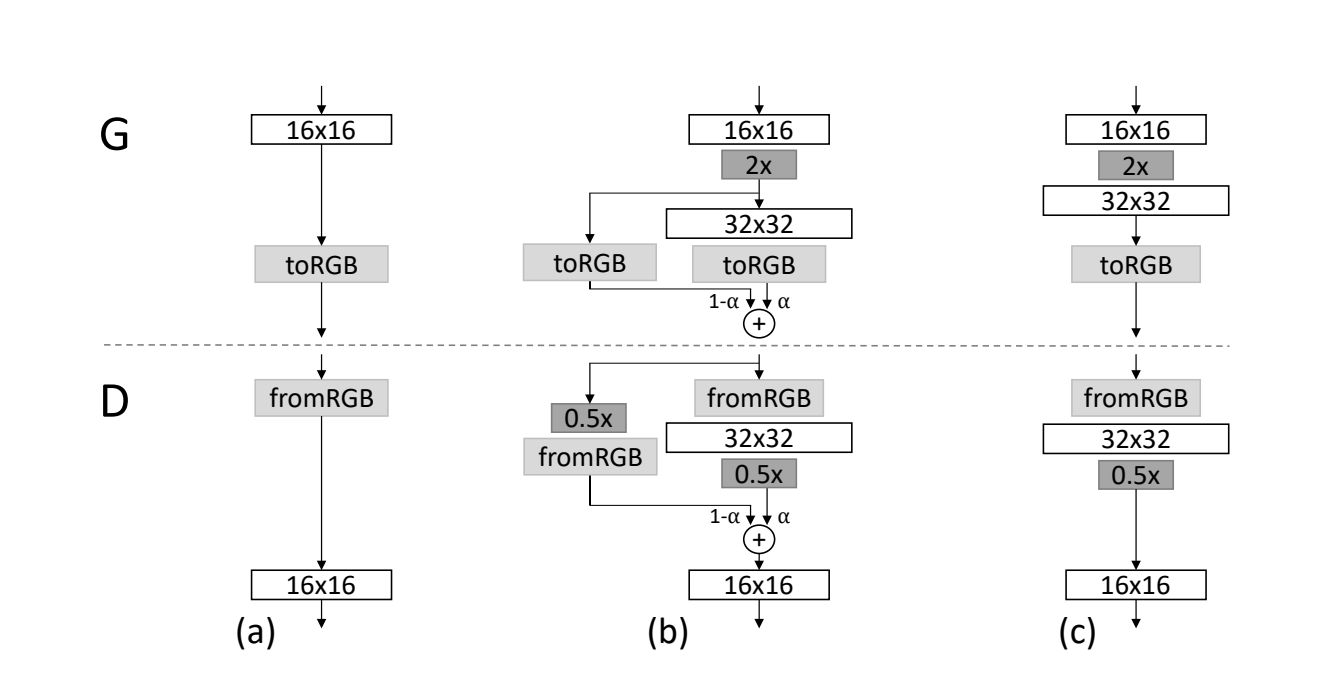


In [ ]:
class DiscriminatorCell(nn.Module):
  '''
  Discriminator block:
  Parameters:
        in_channels: input channels count
        out_channels: output cahnnels count
        alpha: fade in parameter
        down: perform downscale or not
  '''
  def __init__(self, in_channels, out_channels, device):
    super(DiscriminatorCell, self).__init__()

    self.conv1 = EqualizedConv(in_channels, out_channels)
    self.conv2 = EqualizedConv(out_channels, out_channels)

    self.leaky_relu = nn.LeakyReLU(0.2)

  
  def forward(self, x):
    x = self.leaky_relu(self.conv1(x))
    x = self.leaky_relu(self.conv2(x))

    return x


In [ ]:
disc_block = DiscriminatorCell(32, 64, 'cuda')

In [ ]:
t = torch.normal(0, 1, (16, 32, 8, 8))

In [ ]:
disc_block(t)

tensor([[[[ 7.2006e-01,  6.7405e-01,  2.1375e+00,  ...,  1.1150e+00,
           -6.6189e-01, -3.5543e-02],
          [-6.9276e-02,  1.8195e-01, -1.7915e-01,  ...,  3.9841e-01,
           -6.3353e-03,  5.7512e-01],
          [-8.3646e-02,  1.5801e+00, -2.7413e-01,  ..., -5.0640e-02,
           -1.3763e-01,  6.5098e-01],
          ...,
          [ 1.2035e+00,  1.4809e+00,  9.4425e-01,  ..., -2.4656e-01,
           -2.4846e-01,  8.6896e-01],
          [ 7.1724e-01,  8.4746e-01, -5.9036e-01,  ...,  3.8451e-01,
           -2.4526e-01,  2.4521e-01],
          [-1.7099e-01, -2.1724e-01,  2.0243e-01,  ...,  2.1351e+00,
            1.8088e-01,  6.8896e-01]],

         [[ 5.7573e-01, -3.0640e-02, -2.1073e-01,  ..., -1.1049e-01,
           -1.2213e-01,  5.3270e-01],
          [ 1.2858e-01, -1.8909e-01,  7.5582e-01,  ..., -2.8767e-01,
            1.0082e+00,  5.1069e-01],
          [-4.0718e-01, -1.8898e-01,  2.7759e+00,  ...,  2.4584e+00,
            5.4356e-01,  1.9827e-01],
          ...,
     

In [ ]:
class FinalDiscriminatorBlock(nn.Module):
  '''
  Discriminator last predictive layers
  '''

  def __init__(self, input, output, w_dim, kernel_size=4, stride=1, padding=0):
    super(FinalDiscriminatorBlock, self).__init__()
    self.conv1 = EqualizedConv(input, output, kernel_size=3, stride=1, padding=1)
    self.conv2 = EqualizedConv(output, output, kernel_size, stride, padding)
    self.flatten = nn.Flatten()
    self.relu = nn.ReLU()
    self.linear = EqualizedLinear(w_dim, 1)

  def forward(self, x):
    return self.linear(self.flatten(self.relu(self.conv2(self.relu(self.conv1(x)))))) 


In [ ]:
class Discriminator(nn.Module):
  '''
  Discriminator architecture:
  Parameters:
        input_channels: input discriminator cells channels 
        output_channels: output discriminator cells chennels
        img_sizes: img sizes
        alphas: alpha coeficients
        w_dim: W space dimension

  '''
  def __init__(self, 
               input_channels, 
               output_channels, 
               w_dim, 
               device,
               img_channels=3):
    super(Discriminator, self).__init__()
    
    self.w_dim = w_dim
    self.depth = len(input_channels)

    self.avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

    self.disc_blocks = nn.ModuleList()
    self.from_rgb_blocks = nn.ModuleList()

    for i in range(len(input_channels)-1):
      disc_block = DiscriminatorCell(input_channels[i], output_channels[i], device)
      self.disc_blocks.append(disc_block)
      
      from_rgb_block = EqualizedConv(img_channels, input_channels[i], kernel_size=1, stride=1, padding=0)
      self.from_rgb_blocks.append(from_rgb_block.to(device))

    self.disc_blocks.append(DiscriminatorCell(input_channels[-1], output_channels[-1], device))
    self.from_rgb_blocks.append(EqualizedConv(img_channels, input_channels[-1], kernel_size=1, stride=1, padding=0).to(device))

    self.final_block = FinalDiscriminatorBlock(input_channels[-1]+1, output_channels[-1], w_dim)
  
  def fade_in(self, downscaled, x, alpha):
    '''
    Fades in images
    '''
    return (1 - alpha) * downscaled + alpha * x

  def minibatch_statistics(self, x):
    batch_statistics = torch.std(x, dim=0).mean().repeat(x.shape[0], 1, x.shape[2], x.shape[3])
    return torch.cat([x, batch_statistics], dim=1)

  def forward(self, x, steps, alpha):
    pos = self.depth - steps

    x_copy = x.clone()
    x = self.from_rgb_blocks[pos](x)
    if steps > 1:
      down_block = self.avg_pool(x_copy) 
      down_from_rgb = self.from_rgb_blocks[pos+1](down_block)
      x = self.disc_blocks[pos](x)
      down = self.avg_pool(x)
      x = self.fade_in(down_from_rgb, down, alpha)
    
    for i in range(pos+1, self.depth-1):
      x = self.disc_blocks[i](x)
      x = self.avg_pool(x)

    x = self.disc_blocks[self.depth-1](x)

    x = self.minibatch_statistics(x)
    x = self.final_block(x)

    return x      

In [ ]:
disc = Discriminator(output_channels[::-1], input_channels[::-1], w_dim, 'cuda').cuda()

In [ ]:
t = torch.normal(0, 1, (2, 3, 512, 512)).cuda()

In [ ]:
m = disc(t, 8, 0.5)

In [ ]:
m

tensor([[-0.3971],
        [-0.3974]], device='cuda:0', grad_fn=<AddBackward0>)

#Architecture progression test

In [ ]:
steps = len(input_channels)
mapping = Mapping(z_dim, z_dim)
gen = Generator(input_channels, output_channels, mapping, w_dim, device='cuda').cuda()
disc = Discriminator(output_channels[::-1], input_channels[::-1], w_dim, device='cuda').cuda()

for step in range(1, steps):
  print(step)
  batch_size = batch_sizes[step-1]
  w_vectors = torch.normal(0, 1, (batch_size, w_dim)).cuda()

  fake_images = gen(w_vectors, step, 0.5).cuda()
  assert fake_images.shape == (batch_size, 3, img_sizes[step-1], img_sizes[step-1])
  disc_predictions = disc(fake_images, step, 0.5)
  assert disc_predictions.shape == (batch_size, 1)

1
2
3
4
5
6
7


In [ ]:
# GRADED FUNCTION: get_gradient
def get_gradient(crit, real, fake, epsilon, step, alpha):
    '''
    Return the gradient of the critic's scores with respect to mixes of real and fake images.
    Parameters:
        crit: the critic model
        real: a batch of real images
        fake: a batch of fake images
        epsilon: a vector of the uniformly random proportions of real/fake per mixed image
    Returns:
        gradient: the gradient of the critic's scores, with respect to the mixed image
    '''
    # Mix the images together
    mixed_images = real*epsilon + fake*(1-epsilon)

    # Calculate the critic's scores on the mixed images
    mixed_scores = crit(mixed_images, step, alpha)
    
    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        # Note: You need to take the gradient of outputs with respect to inputs.
        # This documentation may be useful, but it should not be necessary:
        # https://pytorch.org/docs/stable/autograd.html#torch.autograd.grad
        #### START CODE HERE ####
        inputs=mixed_images,
        outputs=mixed_scores,
        #### END CODE HERE ####
        # These other parameters have to do with the pytorch autograd engine works
        grad_outputs=torch.ones_like(mixed_scores), 
        create_graph=True,
        retain_graph=True,
    )[0]
    return gradient

In [ ]:
def gradient_penalty(gradient):
    '''
    Return the gradient penalty, given a gradient.
    Given a batch of image gradients, you calculate the magnitude of each image's gradient
    and penalize the mean quadratic distance of each magnitude to 1.
    Parameters:
        gradient: the gradient of the critic's scores, with respect to the mixed image
    Returns:
        penalty: the gradient penalty
    '''
    # Flatten the gradients so that each row captures one image
    gradient = gradient.view(len(gradient), -1)

    # Calculate the magnitude of every row
    gradient_norm = gradient.norm(2, dim=1)
    
    # Penalize the mean squared distance of the gradient norms from 1
    #### START CODE HERE ####
    penalty = torch.mean((gradient_norm - 1)**2)
    #### END CODE HERE ####
    return penalty

In [ ]:
def get_gen_loss(crit_fake_pred):
    '''
    Return the loss of a generator given the critic's scores of the generator's fake images.
    Parameters:
        crit_fake_pred: the critic's scores of the fake images
    Returns:
        gen_loss: a scalar loss value for the current batch of the generator
    '''
    #### START CODE HERE ####
    gen_loss = -torch.mean(crit_fake_pred)
    #### END CODE HERE ####
    return gen_loss

In [ ]:
def get_crit_loss(crit_fake_pred, crit_real_pred, gp, step, alpha, c_lambda):
    '''
    Return the loss of a critic given the critic's scores for fake and real images,
    the gradient penalty, and gradient penalty weight.
    Parameters:
        crit_fake_pred: the critic's scores of the fake images
        crit_real_pred: the critic's scores of the real images
        gp: the unweighted gradient penalty
        c_lambda: the current weight of the gradient penalty 
    Returns:
        crit_loss: a scalar for the critic's loss, accounting for the relevant factors
    '''
    #### START CODE HERE ####
    crit_loss = torch.mean(crit_fake_pred) - torch.mean(crit_real_pred) + c_lambda*gp
    #### END CODE HERE ####
    return crit_loss

WGAN-GP

In [ ]:
def get_noise(batch_size, z_dim, device):
  '''
  Function maps vectors from z dimension to w dimension:
  Parameters:
        batch_size: vector count to generate
        z_dim: dimensionof z space
        mapping: layers to map z space to w space
        device: device name to create tensor
  '''
  noise = torch.normal(0, 1, (batch_size, z_dim), device=device)
  return noise

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu' 
a = 0.001
c_lambda = 10
beta1 = 0
beta2 = 0.99
seen_images = 4*1e5
mapping = Mapping(z_dim, w_dim).to(device)

steps = len(alphas)
gen = Generator(input_channels, output_channels, mapping, w_dim, device=device).to(device)
gen_opt = torch.optim.Adam(gen.parameters(), lr=a, betas=(beta1, beta2))

disc = Discriminator(output_channels[::-1], input_channels[::-1], w_dim, device=device).to(device)
disc_opt = torch.optim.Adam(disc.parameters(), lr=a, betas=(beta1, beta2))

n_critic = 3

disc_hist = []
gen_hist = []

In [ ]:
for step in range(1, steps):
  batch_size = batch_sizes[step-1]
  img_size = img_sizes[step-1]

  transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x*2-1)
  ])
  dataset = FFHQDataset(dir_name, transform)
  data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
  part = seen_images // 8 
  count = 0
  print(step)
  while count < 2*seen_images :
    coef = int(count // part) 
    if coef > 7:
      coef = 7
    alpha = alphas[coef]
    print(alpha)

    mean_iteration_critic_loss = 0
    for _ in range(n_critic):

        real = next(iter(data_loader)).to(device)
        batch_size = real.shape[0]
        count += batch_size
        ### Update critic ###
        disc_opt.zero_grad()
        fake_noise = get_noise(batch_size, z_dim, device=device)
        fake = gen(fake_noise, step, alpha)
        crit_fake_pred = disc(fake.detach(), step, alpha)
        crit_real_pred = disc(real, step, alpha)

        epsilon = torch.rand(len(real), 1, 1, 1, device=device, requires_grad=True)
        gradient = get_gradient(disc, real, fake.detach(), epsilon, step, alpha)
        gp = gradient_penalty(gradient)
        crit_loss = get_crit_loss(crit_fake_pred, crit_real_pred, gp, step, alpha, c_lambda)

        # Keep track of the average critic loss in this batch
        mean_iteration_critic_loss += crit_loss.item() / n_critic
        # Update gradients
        crit_loss.backward(retain_graph=True)
        # Update optimizer
        disc_opt.step() 

    gen_opt.zero_grad()
    fake_noise_2 = get_noise(batch_size, z_dim, device=device)
    fake_2 = gen(fake_noise_2, step, alpha)
    crit_fake_pred = disc(fake_2, step, alpha)
        
    gen_loss = get_gen_loss(crit_fake_pred)
    gen_loss.backward()

    # Update the weights
    gen_opt.step()
    disc_hist.append(mean_iteration_critic_loss)
    gen_hist.append(gen_loss.item())

    print('disc_loss : ', disc_hist[-1], 'gen_loss : ', gen_hist[-1])
    

  



1
0.1
disc_loss :  0.7227658033370972 gen_loss :  0.7754411697387695
0.1
disc_loss :  -0.9791124661763508 gen_loss :  2.4109089374542236
0.1
disc_loss :  -1.9008972644805908 gen_loss :  3.441777229309082
0.1
disc_loss :  -2.397191683451335 gen_loss :  4.028077125549316
0.1
disc_loss :  -2.696752150853475 gen_loss :  4.5165276527404785
0.1
disc_loss :  -2.9180057843526206 gen_loss :  4.54560661315918
0.1
disc_loss :  -3.029191255569458 gen_loss :  4.620108604431152
0.1
disc_loss :  -3.142228126525879 gen_loss :  4.904847145080566
0.1
disc_loss :  -3.101752122243245 gen_loss :  4.8312788009643555
0.1
disc_loss :  -3.341128985087077 gen_loss :  5.0667290687561035
0.1
disc_loss :  -3.3797043164571123 gen_loss :  4.8052568435668945
0.1
disc_loss :  -3.5485024452209473 gen_loss :  5.142242908477783
0.1
disc_loss :  -3.5407162507375087 gen_loss :  5.163611888885498
0.1
disc_loss :  -3.516290108362834 gen_loss :  5.143805980682373
0.1
disc_loss :  -3.6333703200022374 gen_loss :  4.890731811523

KeyboardInterrupt: ignored

Real images example

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x*2-1)
  ])
dataset = FFHQDataset(dir_name, transform)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
data = next(iter(data_loader))

In [ ]:
data.max()

tensor(1.)

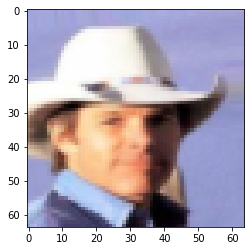

In [ ]:
imshow((((data[5]+1)/2)*255).permute((1, 2, 0)).to(dtype=torch.uint8))

##Show generated images examples

In [ ]:
z = get_noise(10, z_dim, 'cuda')

In [ ]:
images = gen(z, 1, 1.0)

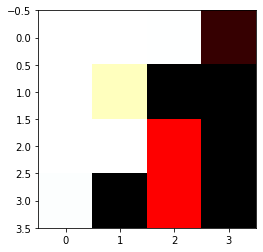

In [ ]:
imshow((((images[7].cpu()+1)/2)*255).permute((1, 2, 0)).to(dtype=torch.uint8))